# Algorithmic Fairness Analysis: COMPAS Recidivism Scoring System

This notebook investigates racial disparities in the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) recidivism risk scoring system, replicating and extending the methodology introduced by ProPublica's *Machine Bias* investigation (Angwin et al., 2016).

The analysis covers:
- Exploratory data analysis of the Broward County dataset
- Comparative COMPAS score distributions across racial groups
- Computation of fairness metrics: False Positive Rate (FPR), Positive Predictive Value (PPV), and High-Risk Rate
- Discussion of Independence, Separation, and Sufficiency as competing fairness criteria

**Dataset:** `compas-scores-two-years.csv` — ProPublica's two-year recidivism follow-up for Broward County, Florida  
**Reference:** Angwin et al. (2016). *Machine Bias*. ProPublica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")

raw_data = pd.read_csv("compas-scores-two-years.csv")

print(f"Dataset loaded: {raw_data.shape[0]:,} rows × {raw_data.shape[1]} columns")

Dataset loaded: 7,214 rows × 53 columns


## 1. Data Overview

In [2]:
print("Shape:", raw_data.shape)
print("\nColumns:")
print(raw_data.columns.tolist())
raw_data.head(3)

Shape: (7214, 53)

Columns:
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1


## 2. Data Filtering

Following ProPublica's methodology, we retain only records where the time between screening and arrest is 30 days or fewer (`|days_b_screening_arrest| ≤ 30`). This ensures the COMPAS score was generated close in time to the actual arrest, reducing noise from stale assessments.

In [3]:
df = raw_data[raw_data["days_b_screening_arrest"].abs() <= 30].copy()

print(f"Records after filter: {len(df):,}  (removed {len(raw_data) - len(df):,} rows)")
print(f"\nRacial group counts:\n{df['race'].value_counts()}")

Records after filter: 6,172  (removed 1,042 rows)

Racial group counts:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


## 3. Descriptive Statistics

Summary of key demographic and outcome variables across the filtered dataset.

In [4]:
summary_cols = ["race", "sex", "age_cat", "two_year_recid", "v_decile_score"]

for col in summary_cols:
    print(f"\n{'='*40}\n{col}\n{'='*40}")
    print(df[col].value_counts(dropna=False).to_string())


race
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11

sex
sex
Male      4997
Female    1175

age_cat
age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293

two_year_recid
two_year_recid
0    3363
1    2809

v_decile_score
v_decile_score
1     1676
2      923
3      833
4      685
5      587
6      508
7      376
8      254
9      231
10      99


## 4. COMPAS Score Distribution

### 4.1 Full Dataset

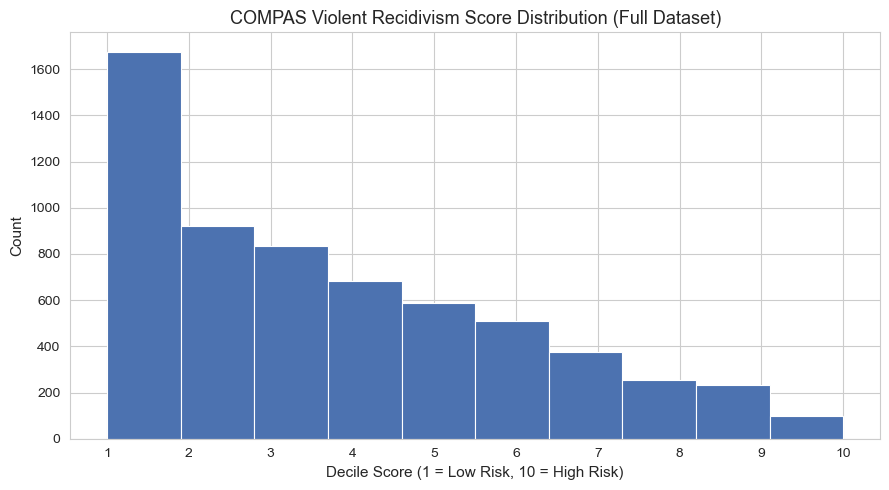

In [5]:
fig, ax = plt.subplots()
ax.hist(df["v_decile_score"].dropna(), bins=10, edgecolor="white", color="#4C72B0", linewidth=0.8)
ax.set_title("COMPAS Violent Recidivism Score Distribution (Full Dataset)")
ax.set_xlabel("Decile Score (1 = Low Risk, 10 = High Risk)")
ax.set_ylabel("Count")
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

### 4.2 Score Distribution by Race (African-American vs. Caucasian)

A side-by-side comparison reveals systematic differences in score distributions between racial groups, despite similar overall recidivism base rates.

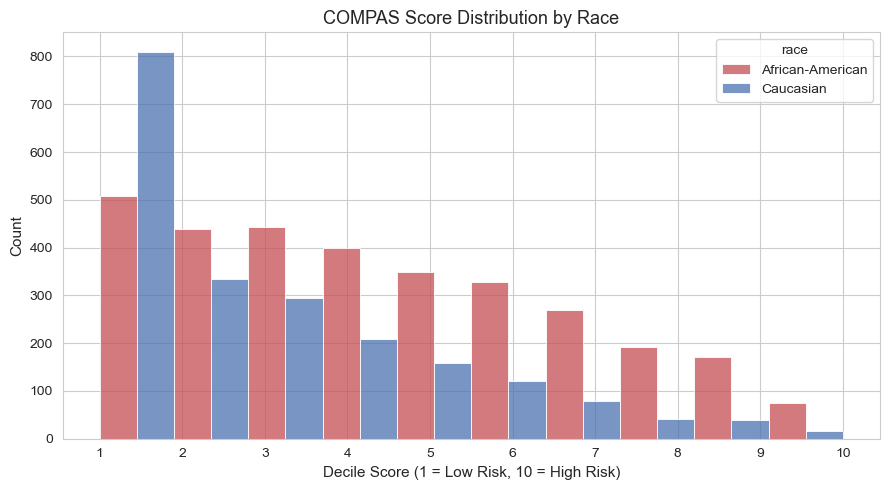

In [6]:
race_subset = df[df["race"].isin(["African-American", "Caucasian"])].copy()

palette = {"African-American": "#C44E52", "Caucasian": "#4C72B0"}

fig, ax = plt.subplots()
sns.histplot(
    data=race_subset,
    x="v_decile_score",
    hue="race",
    bins=10,
    multiple="dodge",
    palette=palette,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)
ax.set_title("COMPAS Score Distribution by Race")
ax.set_xlabel("Decile Score (1 = Low Risk, 10 = High Risk)")
ax.set_ylabel("Count")
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 5. Fairness Metrics

We binarize the COMPAS decile score using the threshold employed by ProPublica:
- **Low risk**: scores 1–4
- **High risk**: scores 5–10

For each racial group we compute three widely-used fairness metrics:

| Metric | Formula | What it tests |
|---|---|---|
| **High-Risk Rate** | P(ŷ = 1) | Overall rate of high-risk labels |
| **False Positive Rate (FPR)** | FP / (FP + TN) | Fraction of non-recidivists labeled high risk |
| **Positive Predictive Value (PPV)** | TP / (TP + FP) | Fraction of high-risk labels that recidivate |

These metrics relate to formal fairness criteria: **Separation** requires equal FPR and TPR across groups; **Sufficiency** requires equal PPV and NPV; **Independence** requires equal high-risk rates.

In [7]:
df["risk_binary"] = np.where(df["v_decile_score"] >= 5, 1, 0)

bw = df[df["race"].isin(["African-American", "Caucasian"])].copy()
black = bw[bw["race"] == "African-American"]
white = bw[bw["race"] == "Caucasian"]


def high_risk_rate(data):
    return data["risk_binary"].mean()


def false_positive_rate(data):
    fp = ((data["risk_binary"] == 1) & (data["two_year_recid"] == 0)).sum()
    tn = ((data["risk_binary"] == 0) & (data["two_year_recid"] == 0)).sum()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan


def positive_predictive_value(data):
    tp = ((data["risk_binary"] == 1) & (data["two_year_recid"] == 1)).sum()
    fp = ((data["risk_binary"] == 1) & (data["two_year_recid"] == 0)).sum()
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan


results = pd.DataFrame(
    {
        "Group": ["African-American", "Caucasian"],
        "N": [len(black), len(white)],
        "High-Risk Rate": [high_risk_rate(black), high_risk_rate(white)],
        "FPR": [false_positive_rate(black), false_positive_rate(white)],
        "PPV": [positive_predictive_value(black), positive_predictive_value(white)],
    }
).set_index("Group")

results.style.format({"High-Risk Rate": "{:.3f}", "FPR": "{:.3f}", "PPV": "{:.3f}"})

,N,High-Risk Rate,FPR,PPV
Group,,,,
African-American,3175,0.437,0.309,0.662
Caucasian,2103,0.216,0.154,0.567


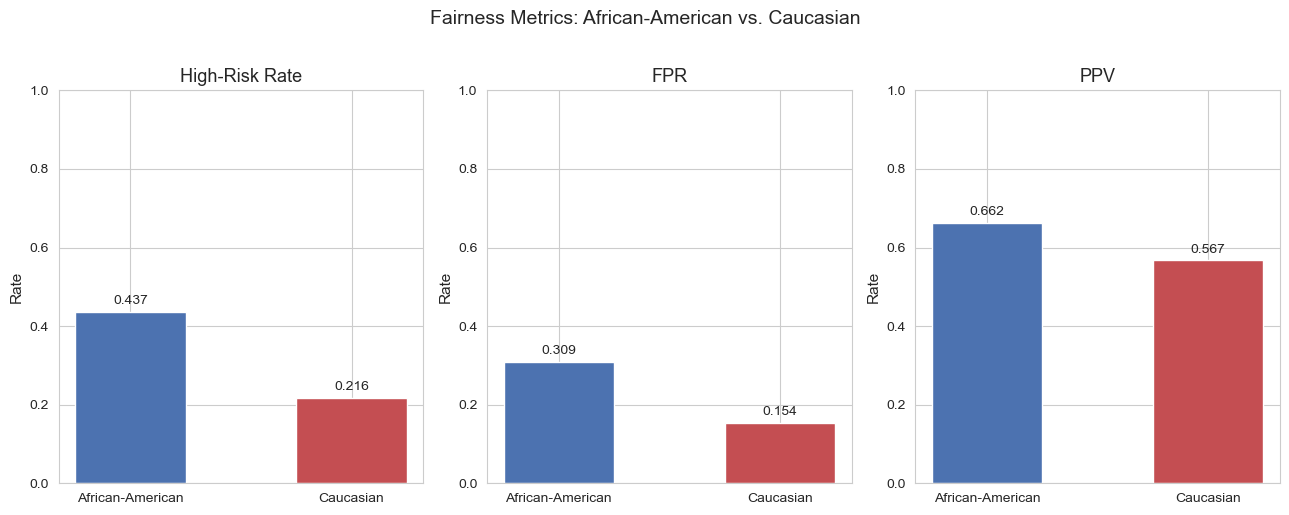

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metrics = ["High-Risk Rate", "FPR", "PPV"]
colors = ["#4C72B0", "#C44E52"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results.index, results[metric], color=colors, edgecolor="white", width=0.5)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Rate")
    for bar, val in zip(bars, results[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha="center",
            fontsize=10,
        )

fig.suptitle("Fairness Metrics: African-American vs. Caucasian", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Discussion

### 6.1 Key Findings

The results replicate ProPublica's core finding: **African-American individuals are labeled high-risk at a substantially higher rate than Caucasian individuals**, and they have a notably higher False Positive Rate — meaning non-recidivating Black defendants are more likely to be incorrectly flagged as high risk.

At the same time, the PPV is similar across groups, which is the basis of Northpointe's (the COMPAS vendor's) counter-argument that the system is "equally predictive."

### 6.2 The Impossibility Theorem

Chouldechova (2017) and Kleinberg et al. (2016) formally showed that **Independence, Separation, and Sufficiency cannot all be satisfied simultaneously** when base rates differ across groups. Since recidivism base rates differ between racial groups in this dataset, any algorithm must accept trade-offs:

- Equalizing FPR (Separation) → unequal PPV
- Equalizing PPV (Sufficiency) → unequal FPR
- Equalizing high-risk rates (Independence) → unequal accuracy

Which criterion to prioritize is not a technical question — it is a **normative and policy decision**.

### 6.3 Structural Concerns Beyond Metrics

Even setting aside the impossibility result, several structural issues remain:

1. **Historical bias in training labels**: `two_year_recid` measures re-arrest, not re-offense. Differential policing increases re-arrest rates for Black individuals independent of actual behavior.
2. **Opacity**: COMPAS is a proprietary black-box model, making independent auditing difficult and limiting defendants' right to contest the score.
3. **High-stakes deployment**: Risk scores inform bail, sentencing, and parole decisions — contexts where errors have severe and asymmetric consequences.

### 6.4 Governance Recommendations

Any deployment of algorithmic risk assessment in criminal justice should require:

- **Algorithmic transparency**: Full disclosure of features, model weights, and training data.
- **Mandatory disparate impact audits**: Regular third-party evaluation across demographic groups before and after deployment.
- **Human oversight requirements**: Scores must inform, not replace, human judgment; adversarial review processes for high-stakes decisions.

---

**References**

- Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). *Machine Bias*. ProPublica.
- Chouldechova, A. (2017). Fair prediction with disparate impact: A study of bias in recidivism prediction instruments. *Big Data*, 5(2), 153–163.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2016). *Inherent trade-offs in the fair determination of risk scores*. arXiv:1609.05807.